# <a id='toc1_'></a>[Bericht zur Datenqualität (epi2025_beta) 📉](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Bericht zur Datenqualität (epi2025_beta) 📉](#toc1_)    
  - [Änderungen seit der letzten Version](#toc1_1_)    
  - [Hinweise](#toc1_2_)    
  - [Datenstand 🕥](#toc1_3_)    
  - [Fallzahlen im Verlauf der Jahreslieferungen](#toc1_4_)    
    - [original geliefert](#toc1_4_1_)    
    - [nach Abschluss der Prüfungen im ZfKD](#toc1_4_2_)    
  - [Variablenverteilung](#toc1_5_)    
    - [Diagnosejahr](#toc1_5_1_)    
    - [Diagnosegruppen](#toc1_5_2_)    
    - [Diagnosesicherung](#toc1_5_3_)    
    - [DCO Diagramm](#toc1_5_4_)    
    - [🆕 BL vs EKRNR](#toc1_5_5_)    
    - [DCO](#toc1_5_6_)    
    - [Anteil Mehrfachtumore](#toc1_5_7_)    
    - [Dignität](#toc1_5_8_)    
    - [Grading 1](#toc1_5_9_)    
    - [🚧  Grading 2](#toc1_5_10_)    
    - [Altersgruppen](#toc1_5_11_)    
    - [UICC](#toc1_5_12_)    
    - [TNM-Auflage](#toc1_5_13_)    
    - [Tod](#toc1_5_14_)    
      - [Verteilung der Variable TOD im verarbeiteten Datensatz](#toc1_5_14_1_)    
      - [Verteilung Todesursachen nach ICDT10](#toc1_5_14_2_)    
  - [Plausibilitätsprüfungen](#toc1_6_)    
    - [⚠️ 01-SH](#toc1_6_1_)    
    - [✅ 02-HH](#toc1_6_2_)    
    - [✅ 03-NI](#toc1_6_3_)    
    - [✅ 04-HB](#toc1_6_4_)    
    - [⚠️ 05-NW](#toc1_6_5_)    
    - [🚨 06-HE](#toc1_6_6_)    
    - [✅ 07-RP](#toc1_6_7_)    
    - [✅ 08-BW](#toc1_6_8_)    
    - [✅ 09-BY](#toc1_6_9_)    
    - [✅ 10-SL](#toc1_6_10_)    
    - [✅ 11-GKR (ehemals)](#toc1_6_11_)    
      - [Verteilung der Variable TOD in den original gelieferten Daten](#toc1_6_11_1_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

<br>

## <a id='toc1_1_'></a>[Änderungen seit der letzten Version](#toc0_)
<!-- - bisher wurden folgende Angaben in einer umfangreichen Verarbeitung im workflow umkodiert: `ICDGM10`, `HISC`, `ICDO3`, `DIG`. Diese Umformung wurde deaktiviert, es finden nun nur noch punktuelle Korrekturen statt -->
- Lieferung Daten mit DJ=2024
- ausstehend: `13-MV`

<br>

## <a id='toc1_2_'></a>[Hinweise](#toc0_)
- Bewertungen der Analysen sind mit 💡 markiert
- bei den Plausibilitätsprüfungen weist ein ✅ darauf hin, dass keine Mängel erkennbar sind

<br>

## <a id='toc1_3_'></a>[Datenstand 🕥](#toc0_)

In [ ]:
import os
from pathlib import Path
import pandas as pd
import datetime as dt
from pandas_plots import tbl, pls, hlp
import duckdb as ddb

from connection_helper import sql
import numpy as np

os.environ["DY_MAX"] = "2024"  # set before import
from mod.filters import *

hlp.show_package_version()

dir_db=Path("C://temp") if hlp.get_os(hlp.OperatingSystem.WINDOWS) else Path(os.path.expanduser("~/tmp"))

# file_epi = dir_db/'2025-11-06_data_epi.duckdb'
# file_meta = dir_db/'2025-11-06_meta_epi.duckdb'
file_epi = dir_db/'2026-03-03_data_epi.duckdb'
file_meta = dir_db/'2026-03-03_meta_epi.duckdb'

if not file_epi.exists() or not file_meta.exists():
    raise Exception(f"files {file_epi} or {file_meta} not found")

URL_V2 = 'https://gitlab.opencode.de/robert-koch-institut/zentrum-fuer-krebsregisterdaten/cancerdata-references/-/raw/main/data/v2/'

os.environ['THEME']='light'
os.environ['RENDERER']=''

🐍 3.12.8 | 📦 pandas: 2.3.3 | 📦 numpy: 1.26.4 | 📦 duckdb: 1.4.4 | 📦 pandas-plots: 1.2.14 | 📦 connection-helper: 0.13.3


In [2]:
sql.print_meta(file_epi)

database file:           2026-03-03_data_epi.duckdb
data tag:                epi2024_2
sql table created:       2026-03-03 09:47:44
doi:                     10.18444/5.03.01.0005.0020.0002
document created:        2026-03-11 18:34:38


In [ ]:
FILTERS_DY_RANGE = ("z_dy between 2019 and 2025", "DJ 2019-2025")

In [4]:
_=con = ddb.connect()
_=con.execute("PRAGMA disable_progress_bar;")
_=con.execute(f"ATTACH DATABASE '{file_epi}' AS epi (READ_ONLY);")
_=con.execute(f"ATTACH DATABASE '{file_meta}' AS meta (READ_ONLY); set schema 'epi';")

In [5]:

# dim_dig = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/dig.csv", sep=";")
# dim_dsich_epi = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/diagnosesicherung_epi.csv", sep=";")
# dim_grading_epi = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/grading_epi.csv", sep=";")
# dim_icd10_3d = sql.load_file_to_duckdb(con, URL_V2 + "Aggregationen/icd10_3d.csv", sep=";")
dim_lieferregister = con.table("dim_lieferregister").to_df()

In [6]:
Batches = con.sql("select * from meta.Batches;")
Checks = con.sql("select * from meta.Checks;")
ColumnCheck = con.sql("select * from meta.ColumnCheck;")
Frequencies = con.sql("select * from meta.Frequencies;")
# _meta_meta = con.sql("select * from meta._meta;")

df_checks = Checks.to_df().astype({"EKRNR": str})
df_freqs = (
    Frequencies.project(
        "*, concat(cast(BatchID as varchar),' | ', cast(cast(BatchZeit as date) as varchar)) as batch_label"
    )
    .to_df()
    .astype({"EKRNR": str})
)
df_freqs["EKRNR"] = df_freqs["EKRNR"].astype(int).replace(dim_lieferregister["kkr"].to_dict())
df_checks["EKRNR"] = df_checks["EKRNR"].astype(int).replace(dim_lieferregister["kkr"].to_dict())
df_batches= Batches.to_df()
df_columnchecks= ColumnCheck.to_df().set_index('ColumnCheckID')
df_checks = df_checks.join(df_columnchecks, on='ColumnCheckID')
df_checks["check_label"] = df_checks.apply(lambda x: f"{x['Alias']}[{x['ColumnCheckID']}]", axis=1)
df_checks= df_checks[["EKRNR","Anzahl","BatchID","DJahr","check_label","ColumnCheckID"]]

In [7]:
db_epi = con.sql("select * from tumor_epi_clin_all;")

In [8]:
batch_max=df_checks['BatchID'].max()
batch_list = [batch_max,418,416,399,360]
batch_min=399
db_list_dy="(2024)"    # must be a str list, since "alt" is in dy col - or a ddb compatible str

In [9]:
print(f"\n{'aktuellster batch': <32}{batch_max}")
print(f"{'aktuellstes Diagnosejahr 📆': <30} {db_list_dy}")


aktuellster batch               425
aktuellstes Diagnosejahr 📆     (2024)


<div style="page-break-after: always;"></div>

## <a id='toc1_4_'></a>[Fallzahlen im Verlauf der Jahreslieferungen](#toc0_)
- kein Filter
- es werden Datenstände (_batch_) aus mehreren Lieferjahren dargestellt , welche über eine laufende Nummer sowie das Datum der Ausführung vergleichbar sind
- in Abgrenzung zu den klinischen Daten ist jede einzelne EKR Lieferung für das gesamte Lieferjahr gültig

<br>

### <a id='toc1_4_1_'></a>[original geliefert](#toc0_)
- aufgeführt sind die Fallzahlen aus den überlieferten Dateien **vor** den ZfKD Anpassungen
- `batch_label` markiert den jeweils letzten offiziellen Datenstand des Lieferjahres, sowie den aktuellen Datenstand

In [10]:
# from tkinter import font


_df=df_freqs[(df_freqs.Stufe==2) & (df_freqs.Alias=="SEX") & (df_freqs.BatchID.isin(batch_list))]
_df=_df.pivot_table(index="batch_label", columns="EKRNR", values="Anzahl", aggfunc="sum")
tbl.show_num_df(
    _df,
    total_axis="y",
    data_bar_axis="x",
    font_size_th=13,
    font_size_td=11,
    col1_width=100,
)

EKRNR,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-GKR,Total
batch_label,,,,,,,,,,,,
360 | 2023-01-03,624_239,371_807,1_545_623,132_265,2_906_452,782_871,632_930,766_070,1_535_587,360_943,3_605_815,13_264_602
399 | 2024-12-02,734_305,423_109,1_816_413,151_753,3_991_177,918_534,823_343,1_048_203,1_811_372,400_646,3_792_956,15_911_811
416 | 2025-04-01,780_626,445_714,1_911_528,157_932,4_186_192,958_031,863_935,1_152_455,1_916_313,412_559,3_974_287,16_759_572
418 | 2025-06-20,780_626,445_714,1_911_528,157_932,4_186_192,973_597,863_935,1_152_455,1_916_313,412_559,3_950_260,16_751_111
425 | 2026-03-03,824_131,462_565,2_007_107,162_936,4_404_285,1_010_507,903_789,1_259_176,2_030_094,429_016,4_075_410,17_569_016


<br>

### <a id='toc1_4_2_'></a>[nach Abschluss der Prüfungen im ZfKD](#toc0_)
- Filter: jeweils das **letzte DJ** der einzelnen Jahreslieferung
- aufgeführt sind die Fallzahlen aus den überlieferten Dateien **nach** den ZfKD Anpassungen

In [11]:
_df=df_freqs[
    (df_freqs.Stufe==5) & 
    (df_freqs.Alias=="SEX") & 
    (df_freqs.BatchID.isin(batch_list))
    & (df_freqs.DJahr!="alt")
    ]
_df=_df.pivot_table(index="batch_label", columns="EKRNR", values="Anzahl", aggfunc="sum")
tbl.show_num_df(
    _df,
    total_axis="y",
    data_bar_axis="x",
    font_size_th=13,
    font_size_td=11,
    col1_width=100,
)

EKRNR,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-GKR,Total
batch_label,,,,,,,,,,,,
360 | 2023-01-03,32_401,17_099,81_092,6_548,176_210,38_279,25_194,77_968,85_001,11_391,164_812,715_995
399 | 2024-12-02,33_243,18_238,85_016,6_086,193_412,38_294,28_779,78_883,80_929,11_665,162_633,737_178
416 | 2025-04-01,34_512,18_011,86_331,5_068,202_655,30_291,30_000,81_600,84_717,11_076,157_970,742_231
418 | 2025-06-20,34_512,18_011,86_331,5_068,202_655,44_073,30_000,81_320,84_717,11_076,155_450,753_213
425 | 2026-03-03,36_307,17_987,84_692,4_687,191_487,31_633,31_489,82_957,86_674,12_247,125_790,705_950


In [12]:
# # * internal check
# _df=(df_checks[(df_checks.ColumnCheckID==48) & (df_checks.BatchID >= batch_min) & (df_checks.BatchID != 415)].sort_values('BatchID'))
# _df=_df.pivot_table(index="BatchID", columns="EKRNR", values="Anzahl", aggfunc="sum").fillna(0)
# tbl.show_num_df(_df, total_axis="y", data_bar_axis="x")

<div style="page-break-after: always;"></div>

## <a id='toc1_5_'></a>[Variablenverteilung](#toc0_)
<!-- - **Filter:**
  - **🚨 sofern nicht anders angegeben ist der Zeitraum beschränkt auf das höchste Diagnosejahr (für `epi2024`: 2023) 🚨**
  - Diagnosen: ausgeschlossen sind `C44` und alle `D` -->
- ab hier wird nur die aktuelle Datenlieferung dargestellt
- als ungültig markierte Fälle (_A-Prüfungen_) sind in allen Fallzahlen ausgeschlossen
- in den barplots sind die relativen Häufigkeiten von Variablen im Datensatz der Register aufgetragen
- zusätzlich ist die Angabe für alle kkr enthalten (`Total`)
- näherungsweise sind GKZ-Bundesländer verwendet anstatt Lieferregister, um 11-16 aufspannen zu können

In [13]:
# def show_freqs_batch(df: pd.DataFrame, batch: int, alias: str, current_only: bool = False) -> None:
#     if current_only:
#         df=df[df['DJahr'] != 'alt']
#     df=df.loc[
#         (df['BatchID'] == batch)
#         & (df['Alias'] == alias)
#         & (df['Stufe'] == 5)
#         ,['EKRNR','Wert','Anzahl']]
#     return df
#     # pls.plot_stacked_bars(df, orientation='h', normalize=False, relative=True, dropna=False, sort_values=False, caption=f'{alias} {batch_max}', show_total=True)

# # print(f"Mögliche Variablen für Auswertung: \n{df_freqs.Alias.unique()}")
# _aliases=['DJ','DSICH','DCO','DIG','GRAD','ALTGRP', 'UICC','TNMAUFL', 'TOD','GKZAUFL']

# # ! switch from ekr -> bl
# # print(f"{np.array(db_epi.columns)}")
# def show_freqs(alias: str, db_list_dy: str = db_list_dy, incl_c44_and_d = False)-> None:
#     df = db_epi
#     if not incl_c44_and_d:
#         df = (df
#                 .filter("""--sql
#                     left(ICDGM10,3) != 'C44' and left(ICDGM10,1)='C'
#                 """)
#         )
#     df = (df
#             .filter(f"DJ in {db_list_dy}")
#             .filter("GKZbl::int <=16")
#             .filter("is_deleted = 0")
#             .aggregate(f"GKZbl, {alias}, count(*) as cnt")
#             .join(dim_lieferregister, "GKZbl = code", "left")
#             .project("* exclude(code)")
#             .to_df()
#     )

#     return df

# caption_str=lambda alias, batch_max: f"{alias}"

<br>

### <a id='toc1_5_1_'></a>[Diagnosejahr](#toc0_)

In [14]:
_filters = [
    FILTERS_VALID,
    FILTERS_DY_RANGE,
    FILTERS_C,
    FILTERS_NO_C44,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_df = con.sql(f"""--sql
    select
        z_dy,
        GKZbl_label as bl,
    from tumor_epi_clin_all tum
    where {_filter}
    """
).to_df()
# _df
tbl.pivot_df(
    _df,
    data_bar_axis="x",
    pct_axis="",
    total_axis="y",
    font_size_th=11,
    font_size_td=11,
)

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 17_569_016                             (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]: n = 16_964_151  (96.6%) ░░████████████████████████████
└ [DJ 2019-2025]:            n = 4_597_256  (26.2%) ░░░░░░░░░░░░░░░░░░░░░░░███████
└ [ICD10 nur C]:             n = 3_886_792  (22.1%) ░░░░░░░░░░░░░░░░░░░░░░░░██████
└ [keine C44,D04]:           n = 3_143_607  (17.9%) ░░░░░░░░░░░░░░░░░░░░░░░░░█████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and z_dy between 2019 and 2025
and left(z_icd10_3d,1) = 'C'
and z_icd10_3d not in ('C44','D04')
```

</details>

bl,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-GKR,12-BB,13-MV,14-SN,15-ST,16-TH,Total
z_dy,,,,,,,,,,,,,,,,,
2019,21_239,10_827,53_159,4_207,122_915,38_028,27_300,67_929,74_291,7_531,21_388,17_553,10_614,29_101,16_101,13_393,535_576
2020,20_993,10_966,52_251,4_102,118_076,37_558,26_316,64_986,71_852,6_981,20_069,16_821,10_784,27_027,16_153,12_636,517_571
2021,21_862,11_217,52_915,4_009,117_050,37_828,27_950,66_090,74_719,7_462,20_831,17_189,11_148,27_308,15_686,12_952,526_216
2022,21_427,11_176,52_738,4_242,118_908,38_702,27_531,66_004,78_390,7_309,21_138,16_962,10_860,27_402,15_939,12_958,531_686
2023,21_336,11_129,53_709,4_081,122_113,37_782,28_002,66_725,79_282,7_360,21_122,17_631,11_209,28_240,16_434,12_755,538_910
2024,20_990,11_523,51_848,4_002,108_880,27_048,27_003,66_506,73_594,7_330,21_012,17_683,852,27_994,15_796,11_587,493_648


### <a id='toc1_5_2_'></a>[Diagnosegruppen](#toc0_)

> 💡 `ZfKD`: _"Die Anteile für D-Diagnosen sind in etwa vergleichbar, die für C44 unterscheiden sich recht deutlich"_

In [15]:
_filters = [
    FILTERS_VALID,
    FILTERS_DY_MAX,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_df = con.sql(f"""--sql
    select
        --z_dy::text as z_dy,
        GKZbl_label as bl,
        code_kid as icd10_grp,
    from tumor_epi_clin_all tum
    left join dim_icd10_3d icd on tum.z_icd10_3d = icd.code
    where {_filter}
    """
).to_df()
# _df

_=pls.plot_stacked_bars(
    _df,
    orientation="h",
    normalize=False,
    relative=True,
    dropna=False,
    sort_values_index=False,
    show_total=True,
    height=820,
)

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 17_569_016                             (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]: n = 16_964_151  (96.6%) ░░████████████████████████████
└ [DJ 2024]:                   n = 705_950   (4.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and z_dy = 2024
```

</details>

<br>

### <a id='toc1_5_3_'></a>[Diagnosesicherung](#toc0_)

> 💡 `ZfKD`: _"auffällig ist der hohe Anteil an fehlenden Diagnosesicherungen in `08-BW`"_  
> 💡 `ZfKD`: _"keine DCO Markierungen für Fälle aus `05-NW`"_

In [16]:
_filters = [
    FILTERS_VALID,
    FILTERS_DY_MAX,
    FILTERS_C,
    FILTERS_NO_C44,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_df = con.sql(f"""--sql
    select
        --z_dy::text as z_dy,
        GKZbl_label as bl,
        label as DSICH,
    from tumor_epi_clin_all tum
    left join dim_dsich_epi ds on tum.DSICH::text = ds.code
    where {_filter}
    """
).to_df()
# _df

_=pls.plot_stacked_bars(
    _df,
    orientation="h",
    normalize=False,
    relative=True,
    dropna=False,
    sort_values_index=False,
    show_total=True,
    height=700,
)

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 17_569_016                             (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]: n = 16_964_151  (96.6%) ░░████████████████████████████
└ [DJ 2024]:                   n = 705_950   (4.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [ICD10 nur C]:               n = 599_876   (3.4%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [keine C44,D04]:             n = 493_648   (2.8%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and z_dy = 2024
and left(z_icd10_3d,1) = 'C'
and z_icd10_3d not in ('C44','D04')
```

</details>

<!-- <br>

### <a id='toc1_5_4_'></a>[DCO Diagramm](#toc0_)
- **Filter: DJ = 2020-2024, C44 und D-Diagnosen sind ausgeschlossen, GKZbl 01-16**
- die epi Variable `DCO` wird wie folgt gebildet:
  - 1 wenn Diagnosesicherung = 3
  - sonst 2 (auch für Diagnosesicherung missing)  -->

### <a id='toc1_5_6_'></a>[DCO](#toc0_)
- Metrik: Anteil DCO an Gesamtfallzahl in %
<!-- > 💡 für 09-BY sind in dieser Lieferung erheblich weniger DCO Fälle festzustellen -->

In [18]:
_filters = [
    FILTERS_VALID,
    FILTERS_C,
    FILTERS_NO_C44,
    ("z_dy between 2010 and 2024","DJ 2010-2024"),
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

db_dco = con.sql(f"""--sql
    with t_all as (
        select
            GKZbl_label as bl,
            z_is_dco,
            z_dy,
            z_icd10_3d,
            is_deleted,
        from db_epi
    )
    select  bl, z_dy,
            count(*) as cnt,
            sum(z_is_dco) as sum_dco,
            sum(z_is_dco) / cnt * 100 as pct_dco,
    from    t_all
    where {_filter}
    group by all
    union
    select  'Total' as bl,
            z_dy,
            count(*) as cnt,
            sum(z_is_dco) as sum_dco,
            sum(z_is_dco) / cnt * 100 as pct_dco,
    from    t_all
    where {_filter}
    group by all
    """)
# tbl.descr_db(db_dco, "dco data")

tbl.pivot_df(
    db_dco.project("bl, z_dy, pct_dco").to_df(),
    swap=True,
    precision=2,
    pct_axis="",
    total_axis="",
    font_size_th=13,
    font_size_td=11,
)

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 17_569_016                             (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]: n = 16_964_151  (96.6%) ░░████████████████████████████
└ [ICD10 nur C]:            n = 14_973_906  (85.2%) ░░░░░█████████████████████████
└ [keine C44,D04]:          n = 12_161_317  (69.2%) ░░░░░░░░░░████████████████████
└ [DJ 2010-2024]:            n = 7_646_321  (43.5%) ░░░░░░░░░░░░░░░░░█████████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and left(z_icd10_3d,1) = 'C'
and z_icd10_3d not in ('C44','D04')
and z_dy between 2010 and 2024
```

</details>

bl,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-GKR,12-BB,13-MV,14-SN,15-ST,16-TH,Total
z_dy,,,,,,,,,,,,,,,,,
2010,14.04,6.84,8.24,3.35,14.02,17.36,12.12,0,10.66,4.20,7.97,5.28,5.37,3.71,11.37,7.38,9.94
2011,14.33,4.84,7.84,4.33,11.96,16.91,15.18,0,9.70,4.11,7.04,5.37,4.59,3.65,12.52,6.87,9.14
2012,14.85,5.20,8.28,4.48,10.85,17.02,14.54,0,9.31,4.84,12.74,5.77,4.44,3.07,12.19,6.11,8.94
2013,13.91,5.01,7.37,6.33,10.81,18.08,16.79,0,8.78,6.55,12.37,5.55,4.66,2.88,12.68,5.96,8.79
2014,13.90,3.66,7.18,11.47,10.14,18.02,15.95,0.10,8.42,9.96,11.23,5.43,4.16,2.64,11.59,6.40,8.57
2015,13.72,4.05,7.19,7.25,9.60,18.07,11.57,6.18,8.48,8.37,14.01,10.25,9.22,6.25,15.00,9.32,9.61
2016,12.61,2.46,6.79,5.83,9.36,15.48,9.42,5.59,8.96,6.78,15.26,9.93,5.72,5.77,14.10,9.87,9.04
2017,10.59,2.98,6.59,6.15,8.23,14.72,6.02,4.77,8.19,7.00,9.90,7.94,0.19,5.78,14.78,9.15,7.91
2018,8.82,2.44,6.10,5.45,7.18,13.65,7.15,3.92,8.01,6.56,8.87,7.79,0.18,5.65,11.03,10.10,7.24


### <a id='toc1_5_7_'></a>[Anteil Mehrfachtumore](#toc0_)

In [19]:
_filters = [
    # FILTERS_VALID,
    # FILTERS_C,
    # FILTERS_NO_C44,
    ("z_dy between 2010 and 2024","DJ 2010-2024"),
    ("GKZbl::tinyint <= 16", "nur gültige BL"),
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_df = con.sql(f"""--sql
    with t1 as (
        select
            GKZbl_label as bl,
            GKZbl,
            z_is_dco,
            case when IARC like '%A_Mehrfach%' then 1 else 0 end as is_multiple,
            z_dy,
            z_icd10_3d,
            is_deleted,
        from db_epi
    ),
    t2 as (
        select  bl,
                z_dy,
                count(*) as cnt,
                sum(is_multiple) as sum_multiple,
                sum(is_multiple) / cnt * 100 as pct_multiple,
        from    t1
        where {_filter}
        group by all
        union
        select  'Total' as bl,
                z_dy,
                count(*) as cnt,
                sum(is_multiple) as sum_multiple,
                sum(is_multiple) / cnt * 100 as pct_multiple,
        from    t1
        where {_filter}
        group by all
    )
    select * from t2
    """
).to_df()

# _df

tbl.pivot_df(
    _df[["bl", "z_dy", "pct_multiple"]],
    swap=True,
    precision=2,
    pct_axis="",
    total_axis="",
    font_size_th=13,
    font_size_td=11,
)

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 17_569_016                     (100.0%) ██████████████████████████████
└ [DJ 2010-2024]:   n = 11_641_922  (66.3%) ░░░░░░░░░░░███████████████████
└ [nur gültige BL]: n = 11_632_852  (66.2%) ░░░░░░░░░░░███████████████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2010 and 2024
and GKZbl::tinyint <= 16
```

</details>

bl,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-GKR,12-BB,13-MV,14-SN,15-ST,16-TH,Total
z_dy,,,,,,,,,,,,,,,,,
2010,0.10,2.16,0.95,0.03,0.07,0.15,0.11,0.33,0.18,2.78,0.51,0.78,0.73,1.45,0.76,1.21,0.48
2011,0.01,2.22,1.02,0.10,0.09,0.19,0.14,0.41,0.18,2.40,0.63,0.87,1.08,1.46,0.67,1.22,0.50
2012,0.02,1.87,1.04,0.06,0.09,0.14,0.19,0.43,0.17,2.63,0.73,0.85,1.00,1.50,0.70,1.22,0.51
2013,0.01,1.67,1.23,0.11,0.12,0.17,0.25,0.72,0.21,3.19,0.72,0.91,1.02,1.43,0.70,1.38,0.59
2014,0.01,1.28,1.29,0.14,0.18,0.24,0.32,0.86,0.20,5.31,0.76,0.80,0.97,1.45,0.85,1.31,0.66
2015,0.02,1.04,1.42,0.41,0.23,0.10,0.42,0.78,0.17,4.83,0.82,0.76,1.09,1.32,0.89,1.29,0.67
2016,0.24,0.97,1.34,0.38,0.36,0.07,0.63,0.75,0.24,4.80,1.03,1.00,1.05,1.35,1.04,1.23,0.74
2017,0.42,0.90,1.24,0.37,0.64,0.17,0.83,0.76,0.26,4.83,1.73,1.42,1.12,1.53,0.83,1.51,0.88
2018,0.33,0.87,1.37,0.35,0.40,0.19,0.86,0.71,0.26,4.74,1.61,1.48,1.14,1.61,1.10,1.29,0.83


### <a id='toc1_5_5_'></a>[🆕 BL vs EKRNR](#toc0_)
- neue Bundesländer sind nicht aufgeführt, da Daten erst ab 2020 aus Länderregistern

In [17]:
_filters = [
    ("z_kkr < 11", "keine NBL"),
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_db = con.sql(f"""--sql
select
    GKZbl_label as bl,
    --lpad(z_gkzbl::text, 2, '0') as z_gkzbl,
    lpad(z_kkr::text, 2, '0') as z_kkr,
    count(*) as cnt,
from tumor_epi_clin_all
where {_filter}
group by all
""")

# _db.show()

tbl.pivot_df(_db.to_df(), pct_axis="x")

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 17_569_016                (100.0%) ██████████████████████████████
└ [keine NBL]: n = 13_493_606  (76.8%) ░░░░░░░███████████████████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_kkr < 11
```

</details>

z_kkr,01,02,03,04,05,06,07,08,09,10,Total
bl,,,,,,,,,,,
(NA),0,0,0,0,9_615 (0.2%),0,0,0,0,0,9_615 (0.1%)
01-SH,824_131 (100.0%),0,0,0,3_719 (0.1%),0,0,0,0,0,827_850 (6.1%)
02-HH,0,462_565 (100.0%),0,0,2_513 (0.1%),0,0,0,0,0,465_078 (3.4%)
03-NI,0,0,2_007_107 (100.0%),0,113_885 (2.6%),0,0,0,0,0,2_120_992 (15.7%)
04-HB,0,0,0,162_936 (100.0%),2_530 (0.1%),0,0,0,0,0,165_466 (1.2%)
05-NW,0,0,0,0,4_064_517 (92.3%),0,0,0,0,0,4_064_517 (30.1%)
06-HE,0,0,0,0,35_494 (0.8%),1_010_507 (100.0%),0,0,0,0,1_046_001 (7.8%)
07-RP,0,0,0,0,73_870 (1.7%),0,903_789 (100.0%),0,0,0,977_659 (7.2%)
08-BW,0,0,0,0,48_614 (1.1%),0,0,1_259_176 (100.0%),0,0,1_307_790 (9.7%)


<br>

### <a id='toc1_5_8_'></a>[Dignität](#toc0_)

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 17_569_016                             (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]: n = 16_964_151  (96.6%) ░░████████████████████████████
└ [DJ 2020-2024]:            n = 3_814_755  (21.7%) ░░░░░░░░░░░░░░░░░░░░░░░░██████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and z_dy between 2020 and 2024
```

</details>

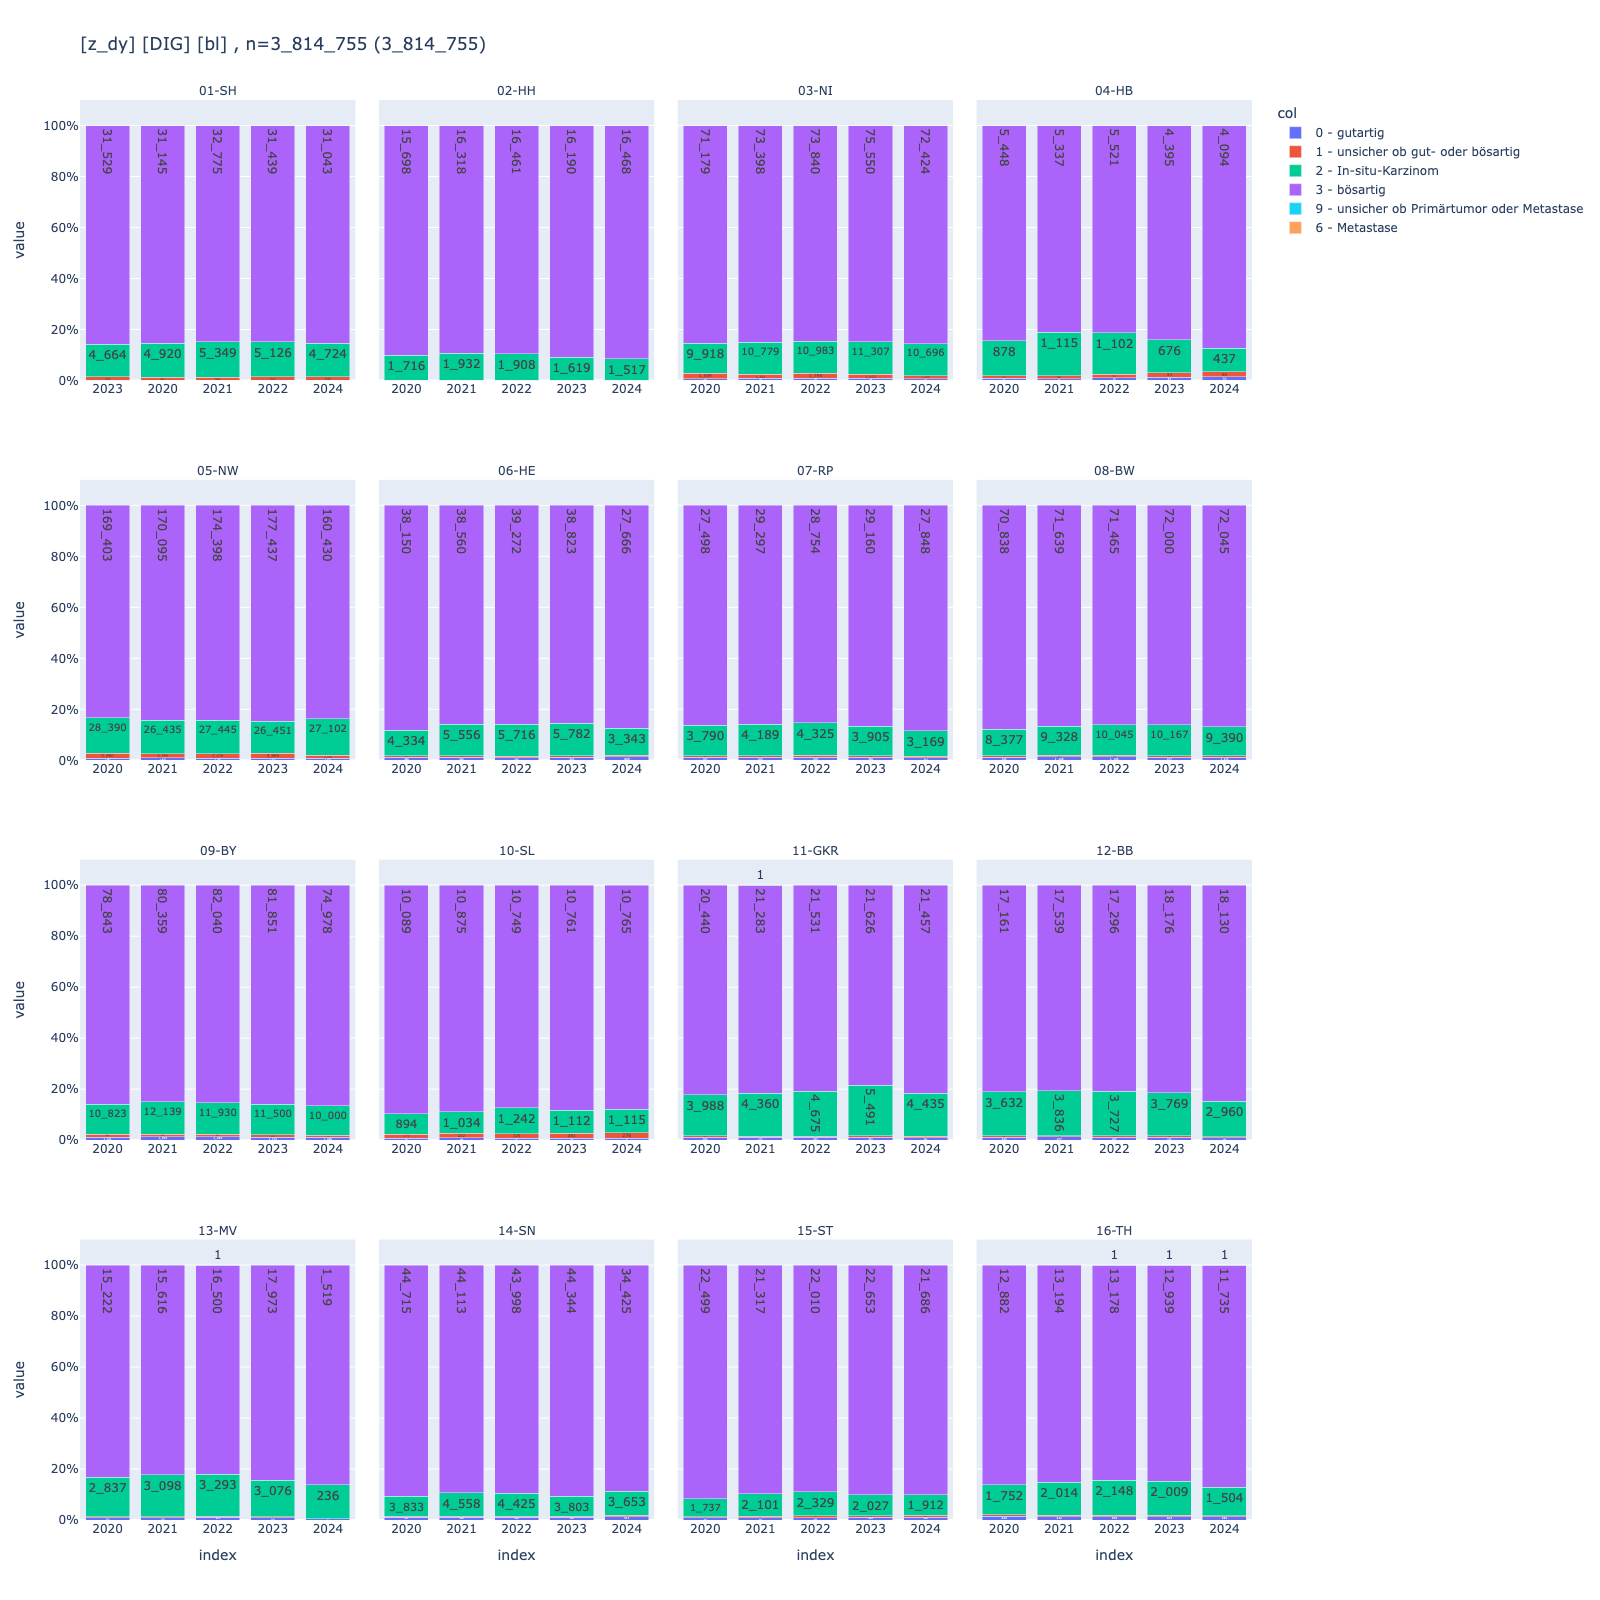

In [20]:
_filters = [
    FILTERS_VALID,
    FILTERS_DY,
    # FILTERS_C,
    # FILTERS_NO_C44,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_df = con.sql(f"""--sql
    select
        z_dy::text as z_dy,
        --DIG,
        label as DIG,
        GKZbl_label as bl,
    from tumor_epi_clin_all tum
    left join dim_dig dig on tum.DIG  = dig.code
    where {_filter}
    """
).to_df()
# _df

_ = pls.plot_facet_stacked_bars(
    _df,
    subplot_size=400,
    relative=True,
    annotations=True,
    sort_values_facet=True,
)

In [21]:
# _df = (
#     db_epi.filter("DJ between 2020 and 2024 and GKZbl::int <= 16")
#     .aggregate("DJ::text as DJ, DIG::text as DIG, GKZbl as bl, count(*) as cnt")
#     .to_df()
# )
# # _df
# _ = pls.plot_facet_stacked_bars(
#     _df,
#     subplot_size=400,
#     relative=True,
#     annotations=True,
#     sort_values_facet=True,
# )

print("GRAD 6")

(con
    .sql("""select * from db_epi where DIG = 6""")
    .aggregate("EKRNR, is_deleted, count(*) as cnt")
    # .filter("not is_deleted")
    .show()
)

GRAD 6
┌─────────┬────────────┬───────┐
│  EKRNR  │ is_deleted │  cnt  │
│ varchar │    int8    │ int64 │
├─────────┼────────────┼───────┤
│ 11      │          0 │     1 │
│ 03      │          1 │     4 │
│ 08      │          1 │  2226 │
│ 11      │          1 │ 10084 │
└─────────┴────────────┴───────┘



<br>

### <a id='toc1_5_9_'></a>[Grading 1](#toc0_)

In [22]:
_filters = [
    FILTERS_VALID,
    FILTERS_DY_MAX,
    FILTERS_C,
    FILTERS_NO_C44,
]

_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_df = con.sql(f"""--sql
    select
        --z_dy::text as z_dy,
        --Grading,
        GKZbl_label as bl,
        label as Grading,
    from tumor_epi_clin_all tum
    left join dim_grading_epi gr on tum.GRAD  = gr.code
    where {_filter}
    """
).to_df()
# display(_df)

_=pls.plot_stacked_bars(
    _df,
    orientation="h",
    normalize=False,
    relative=True,
    dropna=False,
    sort_values_index=False,
    show_total=True,
    height=700,
    show_pct_bar=True,
)

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 17_569_016                             (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]: n = 16_964_151  (96.6%) ░░████████████████████████████
└ [DJ 2024]:                   n = 705_950   (4.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [ICD10 nur C]:               n = 599_876   (3.4%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [keine C44,D04]:             n = 493_648   (2.8%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and z_dy = 2024
and left(z_icd10_3d,1) = 'C'
and z_icd10_3d not in ('C44','D04')
```

</details>

### <a id='toc1_5_10_'></a>[🚧  Grading 2](#toc0_)

In [23]:
_filters = [
    FILTERS_VALID,
    FILTERS_DY,
    FILTERS_NO_DCO,
    FILTERS_GRAD,
]

_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_df=con.sql(query=f"""--sql
    with t1 as (
        select
            z_dy::text as z_dy,
            GKZbl_label as bl,
            GRAD,
            case
                when GRAD is null then '1_null'
                else '2_notnull'
            end as categ_tnm,
        from db_epi
        where {_filter}
    ),
    t2 as (
        select
            z_dy::text as z_dy,
            bl,
            count(*) as cnt,
            count(*) filter (where GRAD is null) as cnt_null,
            cnt_null / cnt as pct_null,
        from t1
        group by all

        union
        select
            'Total' as z_dy,
            bl,
            count(*) as cnt,
            count(*) filter (where GRAD is null) as cnt_null,
            cnt_null / cnt as pct_null,
        from t1
        group by all
        union
        select
            z_dy::text as z_dy,
            'Total' as bl,
            count(*) as cnt,
            count(*) filter (where GRAD is null) as cnt_null,
            cnt_null / cnt as pct_null,
        from t1
        group by all
        
        union
        select
            'Total' as z_dy,
            'Total' as bl,
            count(*) as cnt,
            count(*) filter (where GRAD is null) as cnt_null,
            cnt_null / cnt as pct_null,
        from t1
        group by all

    )
    select * from t2
    """).to_df()
# display(_df)

tbl.pivot_df(
    _df[["z_dy", "bl", "pct_null"]],
    precision=2,
    show_as_pct=True,
    pct_axis="",
    total_axis="",
)


# _=pls.plot_stacked_bars(
#     _df,
#     orientation="h",
#     normalize=False,
#     relative=True,
#     dropna=False,
#     sort_values_index=False,
#     show_total=True,
#     height=700,
#     show_pct_bar=True,
    
# )

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 17_569_016                                  (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]:      n = 16_964_151  (96.6%) ░░████████████████████████████
└ [DJ 2020-2024]:                 n = 3_814_755  (21.7%) ░░░░░░░░░░░░░░░░░░░░░░░░██████
└ [keine DCO]:                    n = 3_643_458  (20.7%) ░░░░░░░░░░░░░░░░░░░░░░░░██████
└ [nur gradingrelevante Tumore]:  n = 1_238_330   (7.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and z_dy between 2020 and 2024
and not z_is_dco
and 
    (
        left(z_icd10_3d, 1) ='C' and
        (
            right(z_icd10_3d, 2)::int8 between 00 and 33
            or right(z_icd10_3d, 2)::int8 between 50 and 57
            or right(z_icd10_3d, 2)::int8 between 63 and 68
            or right(z_icd10_3d, 2)::int8 = 60
        )
        and left(Morphologie_Code,4)::int between 8010 and 8576
    )
```

</details>

bl,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-GKR,12-BB,13-MV,14-SN,15-ST,16-TH,Total
z_dy,,,,,,,,,,,,,,,,,
2020,9.56%,15.66%,30.98%,9.02%,8.82%,12.82%,13.25%,8.81%,9.07%,11.07%,9.17%,8.80%,10.99%,8.82%,9.77%,10.14%,11.93%
2021,9.93%,14.92%,27.33%,9.60%,8.29%,14.00%,14.53%,9.04%,8.90%,10.25%,9.57%,9.40%,10.54%,9.11%,10.56%,9.05%,11.65%
2022,9.88%,14.35%,24.26%,8.78%,8.64%,21.77%,15.69%,9.45%,8.80%,9.62%,9.83%,8.90%,12.12%,9.26%,11.69%,9.99%,12.10%
2023,11.88%,13.96%,20.38%,9.45%,9.55%,23.85%,19.00%,10.78%,8.68%,9.35%,11.11%,9.10%,10.58%,9.45%,11.07%,10.02%,12.44%
2024,12.41%,14.47%,21.40%,9.05%,8.63%,25.68%,20.25%,12.64%,10.07%,11.17%,9.67%,10.92%,10.34%,10.15%,10.87%,13.50%,12.99%
Total,10.70%,14.67%,24.88%,9.18%,8.79%,19.29%,16.52%,10.13%,9.09%,10.28%,9.87%,9.41%,11.03%,9.36%,10.79%,10.44%,12.21%


In [24]:
FILTER = """
        DJ between 2020 and 2024
        and DCO = 2
        and (
        left(ICDGM10, 1) ='C' 
        and
            (
                right(left(ICDGM10,3), 2)::int8 between 00 and 33
                or right(left(ICDGM10,3), 2)::int8 between 50 and 57
                or right(left(ICDGM10,3), 2)::int8 between 63 and 68
                or right(left(ICDGM10,3), 2)::int8 = 60
            )
        and left(HISC,4)::int between 8010 and 8576
        and GKZbl::int between 1 and 16
        )
"""
db_grad=con.sql(query=f"""--sql
    with t1 as (
        select
            GKZbl as bl,
            case
                when GRAD is null then '1_null'
                else '2_notnull' end as categ_tnm,
        from Tumor4
        where True
        and {FILTER}
    )
    select * from t1
""")

# tbl.descr_db(db_grad, "db_grad")

hlp.print_filter(FILTER)

pls.plot_stacked_bars(
    db_grad.to_df().iloc[:,:2],
    relative=True,
    show_total=True,
    orientation="h",
    show_pct_bar=True,
    caption="tum_t",
    height=700,
    width=1600,
    # kkr_col="z_kkr_label"
)


<!-- START_TOKEN -->

-- filter-sql

        DJ between 2020 and 2024
        and DCO = 2
        and (
        left(ICDGM10, 1) ='C' 
        and
            (
                right(left(ICDGM10,3), 2)::int8 between 00 and 33
                or right(left(ICDGM10,3), 2)::int8 between 50 and 57
                or right(left(ICDGM10,3), 2)::int8 between 63 and 68
                or right(left(ICDGM10,3), 2)::int8 = 60
            )
        and left(HISC,4)::int between 8010 and 8576
        and GKZbl::int between 1 and 16
        )



<!-- END_TOKEN -->

<br>

### <a id='toc1_5_11_'></a>[Altersgruppen](#toc0_)

In [25]:
_filters = [
    FILTERS_VALID,
    FILTERS_DY_MAX,
    FILTERS_C,
    FILTERS_NO_C44,
]

_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_df = con.sql(f"""--sql
    select
        --z_dy::text as z_dy,
        GKZbl_label as bl,
        z_ag05,
    from tumor_epi_clin_all tum
    where {_filter}
    """
).to_df()
# display(_df)

_=pls.plot_stacked_bars(
    _df,
    orientation="h",
    normalize=False,
    relative=True,
    dropna=False,
    sort_values_index=False,
    show_total=True,
    height=700,
    show_pct_bar=True,
)

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 17_569_016                             (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]: n = 16_964_151  (96.6%) ░░████████████████████████████
└ [DJ 2024]:                   n = 705_950   (4.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [ICD10 nur C]:               n = 599_876   (3.4%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [keine C44,D04]:             n = 493_648   (2.8%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and z_dy = 2024
and left(z_icd10_3d,1) = 'C'
and z_icd10_3d not in ('C44','D04')
```

</details>

<br>

### <a id='toc1_5_12_'></a>[UICC](#toc0_)
- die Variable `UICC` wird vom ZfKD gebildet

In [26]:
_filters = [
    FILTERS_VALID,
    FILTERS_DY_MAX,
    FILTERS_C,
    FILTERS_NO_C44,
]

_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_df = con.sql(f"""--sql
    select
        GKZbl_label as bl,
        UICC_Stadium_p,
    from tumor_epi_clin_all tum
    where {_filter}
    """
).to_df()
# display(_df)

_=pls.plot_stacked_bars(
    _df,
    orientation="h",
    normalize=False,
    relative=True,
    dropna=False,
    sort_values_index=False,
    show_total=True,
    height=700,
    show_pct_bar=True,
)

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 17_569_016                             (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]: n = 16_964_151  (96.6%) ░░████████████████████████████
└ [DJ 2024]:                   n = 705_950   (4.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [ICD10 nur C]:               n = 599_876   (3.4%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [keine C44,D04]:             n = 493_648   (2.8%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and z_dy = 2024
and left(z_icd10_3d,1) = 'C'
and z_icd10_3d not in ('C44','D04')
```

</details>

<br>

### <a id='toc1_5_13_'></a>[TNM-Auflage](#toc0_)
- nicht übermittelte Auflagen werden im ZfKD geschätzt und imputiert anhand des DJ, daher keine missings

> 💡 `ZfKD`: _"Auflage 7 nur noch von 03-NI in nennenswertem Umfang übermittelt"_

In [27]:
_filters = [
    FILTERS_VALID,
    FILTERS_DY_MAX,
    FILTERS_C,
    FILTERS_NO_C44,
]

_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_df = con.sql(f"""--sql
    select
        GKZbl_label as bl,
        TNM_Auflage_p,
    from tumor_epi_clin_all tum
    where {_filter}
    """
).to_df()
# display(_df)

_=pls.plot_stacked_bars(
    _df,
    orientation="h",
    normalize=False,
    relative=True,
    dropna=False,
    sort_values_index=False,
    show_total=True,
    height=700,
    show_pct_bar=True,
)

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 17_569_016                             (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]: n = 16_964_151  (96.6%) ░░████████████████████████████
└ [DJ 2024]:                   n = 705_950   (4.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [ICD10 nur C]:               n = 599_876   (3.4%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [keine C44,D04]:             n = 493_648   (2.8%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and z_dy = 2024
and left(z_icd10_3d,1) = 'C'
and z_icd10_3d not in ('C44','D04')
```

</details>

<br>

### <a id='toc1_5_14_'></a>[Tod](#toc0_)

#### <a id='toc1_5_14_1_'></a>[Verteilung der Variable TOD im verarbeiteten Datensatz](#toc0_)

In [28]:
_filters = [
    FILTERS_VALID,
    # FILTERS_DY_MAX,
    FILTERS_DY,
    FILTERS_C,
    FILTERS_NO_C44,
]

_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    distinct_metric="GLOBALPATID",
    first_n_filter_apply_to_rows=0,
)

_df = con.sql(f"""--sql
    with t1 as (
    select
        z_pat_id,
        any_value(z_dy::text) as z_dy,
        any_value(GKZbl_label) as bl,
        any_value(Verstorben) as Verstorben,
    from tumor_epi_clin_all
    where {_filter}
    group by z_pat_id
    ),
    t2 as (
        select
            z_dy::text as z_dy,
            bl,
            count(*) as cnt,
            count(*) filter (where Verstorben = 'J') as cnt_deceased,
            cnt_deceased / cnt as pct_deceased,
        from t1
        group by all
        
        union
        select
            'Total' as z_dy,
            bl,
            count(*) as cnt,
            count(*) filter (where Verstorben = 'J') as cnt_deceased,
            cnt_deceased / cnt as pct_deceased,
        from t1
        group by all
        
        union
        select
            z_dy::text as z_dy,
            'Total' as bl,
            count(*) as cnt,
            count(*) filter (where Verstorben = 'J') as cnt_deceased,
            cnt_deceased / cnt as pct_deceased,
        from t1
        group by all
        
        union
        select
            'Total' as z_dy,
            'Total' as bl,
            count(*) as cnt,
            count(*) filter (where Verstorben = 'J') as cnt_deceased,
            cnt_deceased / cnt as pct_deceased,
        from t1
        group by all
    )
    select * from t2
    """
).to_df()
# display(_df)

tbl.pivot_df(
    _df[["z_dy", "bl", "pct_deceased"]],
    total_axis="",
    pct_axis="",
    # show_as_pct=True,
    precision=2,
)

<!-- START_TOKEN -->

counts: distinct GLOBALPATID
---
n = 14_998_886                             (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]: n = 14_585_410  (97.2%) ░█████████████████████████████
└ [DJ 2020-2024]:            n = 3_548_356  (23.7%) ░░░░░░░░░░░░░░░░░░░░░░░███████
└ [ICD10 nur C]:             n = 3_021_090  (20.1%) ░░░░░░░░░░░░░░░░░░░░░░░░██████
└ [keine C44,D04]:           n = 2_486_711  (16.6%) ░░░░░░░░░░░░░░░░░░░░░░░░░░████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and z_dy between 2020 and 2024
and left(z_icd10_3d,1) = 'C'
and z_icd10_3d not in ('C44','D04')
```

</details>

bl,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-GKR,12-BB,13-MV,14-SN,15-ST,16-TH,Total
z_dy,,,,,,,,,,,,,,,,,
2020,0.49,0.44,0.49,0.51,0.47,0.48,0.44,0.42,0.41,0.51,0.44,0.44,0.44,0.46,0.51,0.23,0.45
2021,0.45,0.41,0.45,0.46,0.43,0.44,0.40,0.37,0.38,0.47,0.40,0.42,0.37,0.41,0.46,0.19,0.41
2022,0.41,0.35,0.41,0.42,0.39,0.41,0.36,0.32,0.34,0.41,0.37,0.36,0.32,0.36,0.42,0.16,0.37
2023,0.35,0.28,0.34,0.34,0.31,0.34,0.28,0.25,0.25,0.35,0.30,0.33,0.25,0.29,0.36,0.13,0.30
2024,0.27,0.21,0.23,0.22,0.12,0.25,0.19,0.17,0.14,0.23,0.21,0.22,0.14,0.16,0.23,0.07,0.17
Total,0.40,0.34,0.38,0.39,0.35,0.39,0.34,0.31,0.30,0.39,0.34,0.35,0.34,0.34,0.40,0.16,0.34


#### <a id='toc1_5_14_2_'></a>[Verteilung Todesursachen nach ICDT10](#toc0_)
- gezählt sind **Personen**
- `icdt10_1d` gibt die erste Stelle der Todesursache an

<!-- START_TOKEN -->

counts: distinct GLOBALPATID
---
n = 14_998_886                             (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]: n = 14_585_410  (97.2%) ░█████████████████████████████
└ [nur Verstorbene]:         n = 7_558_161  (50.4%) ░░░░░░░░░░░░░░░███████████████
└ [SJ ab 2010]:              n = 5_099_012  (34.0%) ░░░░░░░░░░░░░░░░░░░░██████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and Verstorben = 'J'
and year(SDIMP) >= 2010
```

</details>

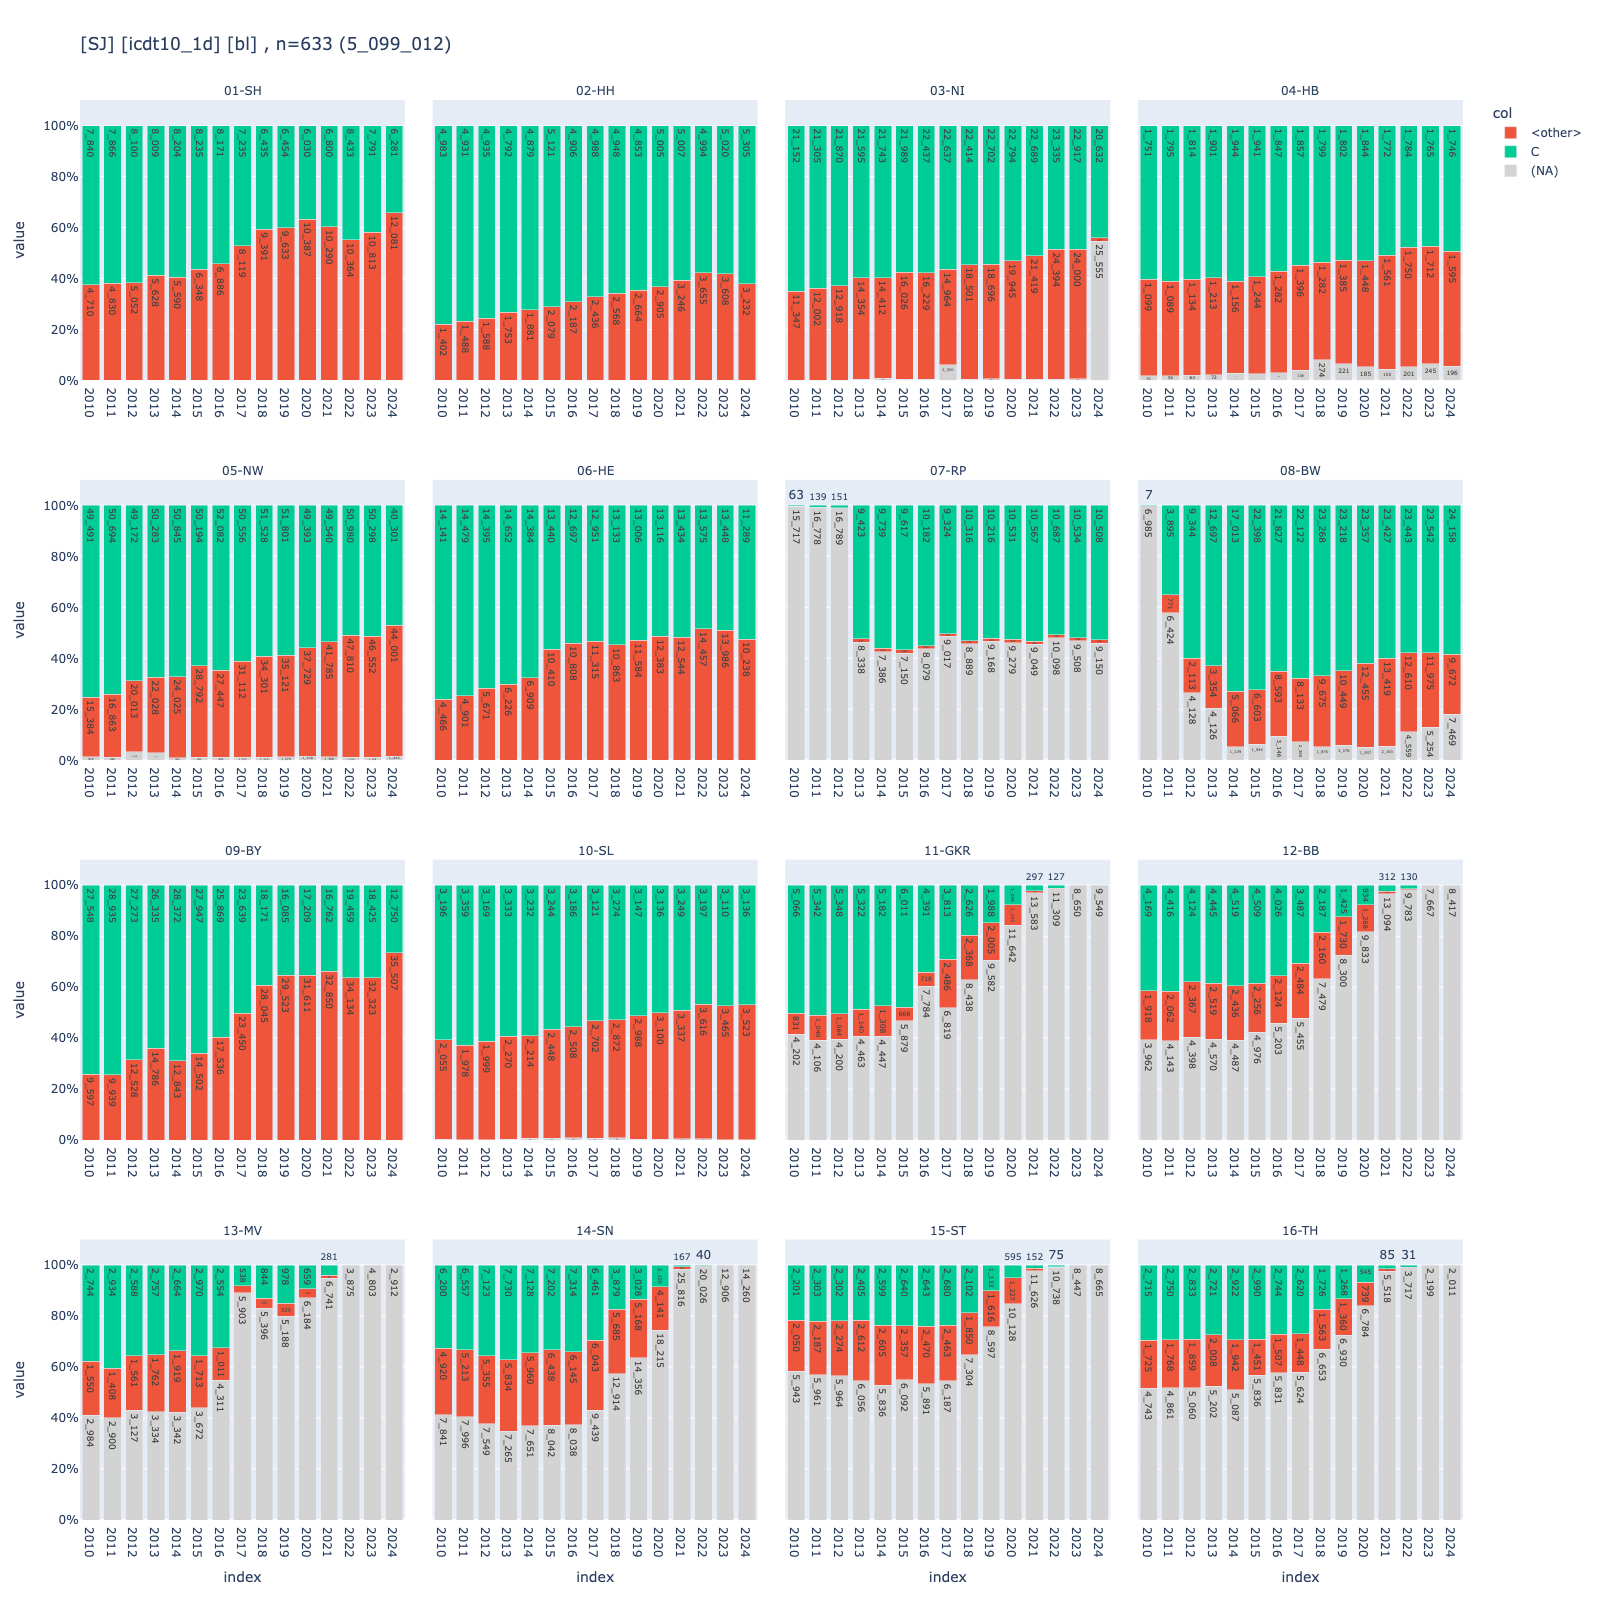

In [29]:
_filters = [
    FILTERS_VALID,
    ("Verstorben = 'J'", "nur Verstorbene"),
    ("year(SDIMP) >= 2010", "SJ ab 2010"),
]

_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    distinct_metric="GLOBALPATID",
    first_n_filter_apply_to_rows=0,
)

_df = (con.sql(f"""--sql
    with t1 as (
        select
            year(SDIMP)::text as SJ,
            ICDT10,
            GKZbl_label as bl,
            case
                when ifnull(ICDT10,'') = '' then null
                when upper(left(ICDT10,1)) = 'C' then 'C'
            else '<other>' end as icdt10_1d,
            GLOBALPATID,
        from tumor_epi_clin_all
        where {_filter}
    ),
    t2 as (
        select 
            any_value(SJ) as SJ,
            any_value(icdt10_1d) as icdt10_1d,
            any_value(bl) as bl,
        from t1
        group by GLOBALPATID
    ),
    t3 as (
        select
            *,
            count(*) as cnt
        from t2
        group by all
    )
    select * from t3
    """)
    # .filter("SJ::int >= 2010 and GKZbl::int <= 16")
    .order("bl")
    .to_df()
)
# display(_df)

_ = pls.plot_facet_stacked_bars(
    _df,
    # df_tu[["SJ","icdt10_1d","GKZbl"]],
    # df_tu[["DJ","ICDT10","EKRNR"]],
    # top_n_color=5,
    subplot_size=400,
    sort_values_facet=True,
    # sort_values_index=True,
    relative=True,
    annotations=True,
)

<div style="page-break-after: always;"></div>

## <a id='toc1_6_'></a>[Plausibilitätsprüfungen](#toc0_)
- **Filter**
  - **es ist jeweils nur das aktuellste DJ berücksichtigt (aktuell: 2024, ins letzter Lieferung: 2023)**
- Die Tabellen sind zur besseren Lesbarkeit nun aufgeteilt nach den Plausibilitätsprüfungen ([pdf](https://www.krebsregisterverbund.de/attachments/download/8743/Plausibilit%C3%A4tspr%C3%BCfungen_details.pdf))
  - `A`: Fälle ausgeschlossen
  - `B`: Fälle markiert
  - `C`: Fälle korrigiert
- Spalten
  - `cnt_epi2024`: Absolute Fallzahl der checks für das in diesem Datensatz höchste DJ (2023)
  - `cnt_now`: Absolute Fallzahl der checks für das im aktuellen Datensatz höchsten DJ (2024)
  - `pct_epi2024`: Anteil Fallzahl der checks an allen Fällen für das in diesem Datensatz höchste DJ (2023)
  - `pct_now`: Anteil Fallzahl der checks an allen Fällen für das im aktuellen Datensatz höchste DJ (2024)
  - _(Absolute Fallzahlen = nach Abzug der A-Prüfungen)_

In [30]:
def show_checks2(df_in: pd.DataFrame, reg: str) -> None:
    
    db = con.from_df(df_in)
    db_total= con.sql(f"""--sql
        select *
        from db
        where BatchID = {batch_max}
        and EKRNR = '{reg}'
        and DJahr <> 'alt'
    """)
    
    
    if db_total.count("*").fetchone()[0] == 0:
        print("❌")
        return

    def get_ser(
        df_in: pd.DataFrame, batch_id: int, reg: str, suffix: str
    ) -> pd.DataFrame:
        df = df_in.copy()

        total = df.loc[
            (df["BatchID"] == batch_id)
            & (df["EKRNR"] == reg)
            & (df["DJahr"] != "alt")
            & (df["check_label"] == "I_Fallzahl[48]"),
            ["BatchID", "check_label", "Anzahl"],
        ].iloc[0, -1]

        df_out = df.loc[
            (df["BatchID"] == batch_id) & (df["EKRNR"] == reg) & (df["DJahr"] != "alt"),
            ["BatchID", "check_label", "Anzahl"],
        ]

        df_out["pct"] = df_out["Anzahl"] / total * 100
        return (
            df_out.rename(columns={"Anzahl": "cnt_" + suffix, "pct": "pct_" + suffix})
            .iloc[:, 1:]
            .reset_index(drop=True)
        )

    df0 = get_ser(df_checks, 418, reg, "epi2024")
    df1 = get_ser(df_checks, batch_max, reg, "now")

    df = (
        pd.merge(df0, df1, on="check_label", how="outer")
        .set_index("check_label")
        .iloc[:, [0, 2, 1, 3]]
    )
    df_ab = df[df.index.str.startswith(("A_", "B_","I_"))]
    df_a = df[df.index.str.startswith(("A_","I_"))]
    df_b = df[df.index.str.startswith(("B_","I_"))]
    df_c = df[df.index.str.startswith(("C_","I_"))]
    display(tbl.show_num_df(df_a, total_axis="", data_bar_axis="x", col1_width=300,font_size_th=13,font_size_td=11,))
    display(tbl.show_num_df(df_b, total_axis="", data_bar_axis="x", col1_width=300,font_size_th=13,font_size_td=11,))
    display(tbl.show_num_df(df_c, total_axis="", data_bar_axis="x", col1_width=300,font_size_th=13,font_size_td=11,))
    return

<br>

### <a id='toc1_6_1_'></a>[⚠️ 01-SH](#toc0_)
- `B_TOD_Ja_Aber_Kein_SJ`: 0 -> 4%
- alle Fälle wurden korrigiert laut `C_TOD=1_korrigiert_aufgrund_Sterbeangaben`

In [31]:
# show_checks(df_checks, batches=batches, reg='01-SH', relative=False)
show_checks2(df_checks, "01-SH")

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_ICD10_SEX_fehlerhaft[66],1,nan,0,nan
A_ICD10_keineAuswertung[54],1,nan,0,nan
A_Mehrfachmeldung[37],121,132,0,0
I_Fallzahl[48],34_512,36_307,100,100


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],12,14,0,0
B_DCO_DDIMP_inkonsistent[39],8,8,0,0
B_DIG_HISC_unplausibel[70],44,53,0,0
B_DIG_ICDO3_unplausibel[69],nan,1,nan,0
B_DSICH_HISC_unplausibel[72],130,102,0,0
B_Entscheidung_Mehrfachtumor_unplausibel[82],4,9,0,0
B_GRAD_HISC_unplausibel[85],44,45,0,0
B_HISC_ICDO3_unplausibel[55],222,209,1,1
B_TNMM_GROBST_unplausibel[78],109,95,0,0


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_DIG_korrigiert[64],2,4,0,0
C_HISC_korrigiert[56],5,7,0,0
C_ICD10DREI_korrigiert[80],156,192,0,1
C_ICDO3_korrigiert[52],43,43,0,0
C_LOKS_korrigiert[84],137,194,0,1
C_SJ>MaxJahr[14],2_555,nan,7,nan
C_TOD=1_korrigiert_aufgrund_Sterbeangaben[74],nan,1_511,nan,4
I_Fallzahl[48],34_512,36_307,100,100


<div style="page-break-after: always;"></div>

### <a id='toc1_6_2_'></a>[✅ 02-HH](#toc0_)

In [32]:
# show_checks(df_checks, batches=batches, reg='02-HH', relative=True)
show_checks2(df_checks, "02-HH")

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_Mehrfachmeldung[37],176,136,1,1
A_SEX_fehlerhaft[1],1,4,0,0
I_Fallzahl[48],18_011,17_987,100,100


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],6,9,0,0
B_DCO_DDIMP_inkonsistent[39],33,25,0,0
B_DIG_HISC_unplausibel[70],197,169,1,1
B_DSICH_HISC_unplausibel[72],243,250,1,1
B_Entscheidung_Mehrfachtumor_unplausibel[82],nan,4,nan,0
B_GRAD_HISC_unplausibel[85],19,20,0,0
B_HISC_ICDO3_unplausibel[55],318,269,2,1
I_Fallzahl[48],18_011,17_987,100,100


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_DJ_korrigiert_aufgrund_DSICH[43],81,76,0,0
C_HISC_korrigiert[56],6,16,0,0
C_ICD10DREI_korrigiert[80],58,57,0,0
C_ICDO3_korrigiert[52],2,3,0,0
C_LOKS_korrigiert[84],216,237,1,1
I_Fallzahl[48],18_011,17_987,100,100


<div style="page-break-after: always;"></div>

### <a id='toc1_6_3_'></a>[✅ 03-NI](#toc0_)

In [33]:
# show_checks(df_checks, batches=batches, reg='03-NI', relative=False)
show_checks2(df_checks, "03-NI")

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_ICD10_keineAuswertung[54],147,147,0,0
A_Mehrfachmeldung[37],1_256,2_010,1,2
A_Zeitangaben_fehlerhaft[58],2,7,0,0
I_Fallzahl[48],86_331,84_692,100,100


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],35,55,0,0
B_DCO_DDIMP_inkonsistent[39],101,90,0,0
B_DIG_HISC_unplausibel[70],420,386,0,0
B_DSICH_HISC_unplausibel[72],697,704,1,1
B_Entscheidung_Mehrfachtumor_unplausibel[82],1,1,0,0
B_GRAD_HISC_unplausibel[85],125,136,0,0
B_HISC_ICDO3_unplausibel[55],1_175,1_092,1,1
B_PatAngaben_inkonsistent[60],2,12,0,0
B_TNMM_GROBST_unplausibel[78],2,3,0,0


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_DIG_korrigiert[64],nan,15,nan,0
C_DJ_korrigiert_aufgrund_DSICH[43],7,11,0,0
C_HISC_korrigiert[56],558,289,1,0
C_ICD10DREI_korrigiert[80],1_235,1_983,1,2
C_LOKS_korrigiert[84],516,378,1,0
C_SJ>MaxJahr[14],6_518,6_002,8,7
C_TNMx_korrigiert[44],166,121,0,0
C_TOD=1_korrigiert_aufgrund_Sterbeangaben[74],5,39,0,0
I_Fallzahl[48],86_331,84_692,100,100


<div style="page-break-after: always;"></div>

### <a id='toc1_6_4_'></a>[✅ 04-HB](#toc0_)

In [34]:
# show_checks(df_checks, batches=batches, reg='04-HB', relative=False)
# show_checks(df_checks, batches=batches, reg='04-HB', relative=True)
show_checks2(df_checks, "04-HB")

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_ICD10_keineAuswertung[54],4,5,0,0
A_Mehrfachmeldung[37],25,14,0,0
A_SEX_fehlerhaft[1],2,nan,0,nan
I_Fallzahl[48],5_068,4_687,100,100


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],6,6,0,0
B_DCO_DDIMP_inkonsistent[39],4,2,0,0
B_DIG_HISC_unplausibel[70],34,85,1,2
B_DSICH_HISC_unplausibel[72],48,32,1,1
B_Entscheidung_Mehrfachtumor_unplausibel[82],1,1,0,0
B_GRAD_HISC_unplausibel[85],12,8,0,0
B_HISC_ICDO3_unplausibel[55],85,114,2,2
B_TNMT_DIG_unplausibel[20],5,3,0,0
B_TNMx_ICD10_unplausibel[76],nan,5,nan,0


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_DIG_korrigiert[64],nan,1,nan,0
C_HISC_korrigiert[56],3,9,0,0
C_ICD10DREI_korrigiert[80],16,13,0,0
C_ICDO3_korrigiert[52],4,nan,0,nan
C_LOKS_korrigiert[84],81,69,2,1
I_Fallzahl[48],5_068,4_687,100,100


In [35]:
# print(f"{np.array(db_epi.columns)}")
# db_epi.filter("EKRNR = '04' and DJ = '2022'").value_counts("IARC")
# db_epi.filter("EKRNR = '04' and DJ = '2022' and IARC like '%1_korrigiert_aufgrund_Sterbeangaben%'").project("TOD, SDIMP")

<div style="page-break-after: always;"></div>

### <a id='toc1_6_5_'></a>[⚠️ 05-NW](#toc0_)
- unverändert hohe werte bei `A_EKRNR_GKZ_unplausibel`

In [36]:
# show_checks(df_checks, batches=batches, reg='05-NW', relative=True)
show_checks2(df_checks, "05-NW")

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_EKRNR_GKZ_unplausibel[83],21_338,22_483,11,12
A_ICD10_keineAuswertung[54],748,682,0,0
A_Mehrfachmeldung[37],255,216,0,0
I_Fallzahl[48],202_655,191_487,100,100


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],99,81,0,0
B_DALT_unplausibel[77],nan,1,nan,0
B_DCO_DDIMP_inkonsistent[39],38,2,0,0
B_DIG_HISC_unplausibel[70],2_026,2_053,1,1
B_DSICH_HISC_unplausibel[72],1_565,1_611,1,1
B_Entscheidung_Mehrfachtumor_unplausibel[82],16,11,0,0
B_GRAD_HISC_unplausibel[85],121,89,0,0
B_HISC_ICDO3_unplausibel[55],2_767,2_910,1,2
B_PatAngaben_inkonsistent[60],1,nan,0,nan


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_HISC_korrigiert[56],527,368,0,0
C_ICD10DREI_korrigiert[80],636,387,0,0
C_ICDO3_korrigiert[52],130,88,0,0
C_LOKS_korrigiert[84],117,184,0,0
C_SJ>MaxJahr[14],15_419,9_680,8,5
C_TNMx_korrigiert[44],1,nan,0,nan
I_Fallzahl[48],202_655,191_487,100,100


<div style="page-break-after: always;"></div>

### <a id='toc1_6_6_'></a>[🚨 06-HE](#toc0_)
- Fallzahl DJ=2024 deutlich geringer

In [37]:
# show_checks(df_checks, batches=batches, reg='06', relative=True)
show_checks2(df_checks, "06-HE")

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_ICD10_keineAuswertung[54],1,2,0,0
A_Mehrfachmeldung[37],114,57,0,0
A_SEX_fehlerhaft[1],nan,3,nan,0
I_Fallzahl[48],44_073,31_633,100,100


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],30,22,0,0
B_DALT_unplausibel[77],1,nan,0,nan
B_DCO_DDIMP_inkonsistent[39],55,28,0,0
B_DIG_HISC_unplausibel[70],285,189,1,1
B_DIG_ICDO3_unplausibel[69],nan,1,nan,0
B_DSICH_HISC_unplausibel[72],560,405,1,1
B_Entscheidung_Mehrfachtumor_unplausibel[82],6,10,0,0
B_GRAD_HISC_unplausibel[85],47,27,0,0
B_HISC_ICDO3_unplausibel[55],709,476,2,2


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_DIG_korrigiert[64],1,1,0,0
C_HISC_korrigiert[56],43,27,0,0
C_ICD10DREI_korrigiert[80],203,105,0,0
C_ICDO3_korrigiert[52],43,22,0,0
C_LOKS_korrigiert[84],178,100,0,0
C_SJ>MaxJahr[14],3_710,1_441,8,5
I_Fallzahl[48],44_073,31_633,100,100


<div style="page-break-after: always;"></div>

### <a id='toc1_6_7_'></a>[✅ 07-RP](#toc0_)

In [38]:
# show_checks(df_checks, batches=batches, reg='07-RP', relative=True)
show_checks2(df_checks, "07-RP")

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_Mehrfachmeldung[37],184,221,1,1
I_Fallzahl[48],30_000,31_489,100,100


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],12,17,0,0
B_DCO_DDIMP_inkonsistent[39],24,20,0,0
B_DIG_HISC_unplausibel[70],240,177,1,1
B_DSICH_HISC_unplausibel[72],563,566,2,2
B_Entscheidung_Mehrfachtumor_unplausibel[82],11,7,0,0
B_GRAD_HISC_unplausibel[85],9,9,0,0
B_HISC_ICDO3_unplausibel[55],545,477,2,2
B_TNMx_ICD10_unplausibel[76],24,25,0,0
I_Fallzahl[48],30_000,31_489,100,100


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_HISC_korrigiert[56],284,261,1,1
C_ICD10DREI_korrigiert[80],202,187,1,1
C_ICDO3_korrigiert[52],16,25,0,0
C_LOKS_korrigiert[84],777,892,3,3
C_SJ>MaxJahr[14],2_047,1_677,7,5
C_TNMx_korrigiert[44],nan,2,nan,0
I_Fallzahl[48],30_000,31_489,100,100


<div style="page-break-after: always;"></div>

### <a id='toc1_6_8_'></a>[✅ 08-BW](#toc0_)

In [39]:
# show_checks(df_checks, batches=batches, reg='08-BW', relative=True)
show_checks2(df_checks, "08-BW")

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_ICD10_keineAuswertung[54],427,349,1,0
A_Mehrfachmeldung[37],444,486,1,1
A_SEX_fehlerhaft[1],6,10,0,0
A_Zeitangaben_fehlerhaft[58],9,13,0,0
I_Fallzahl[48],81_320,82_957,100,100


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],56,65,0,0
B_DCO_DDIMP_inkonsistent[39],16,30,0,0
B_DIG_HISC_unplausibel[70],1_024,1_149,1,1
B_DSICH_HISC_unplausibel[72],515,502,1,1
B_Entscheidung_Mehrfachtumor_unplausibel[82],22,31,0,0
B_GRAD_HISC_unplausibel[85],89,98,0,0
B_HISC_ICDO3_unplausibel[55],1_745,1_938,2,2
B_PatAngaben_inkonsistent[60],2,1,0,0
B_TNMT_DIG_unplausibel[20],139,140,0,0


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_DIG_korrigiert[64],2,nan,0,nan
C_DJ_korrigiert_aufgrund_DSICH[43],6,1,0,0
C_HISC_korrigiert[56],133,153,0,0
C_ICD10DREI_korrigiert[80],471,684,1,1
C_ICDO3_korrigiert[52],27,63,0,0
C_LOKS_korrigiert[84],515,539,1,1
C_SJ>MaxJahr[14],1_018,2_785,1,3
I_Fallzahl[48],81_320,82_957,100,100


<div style="page-break-after: always;"></div>

### <a id='toc1_6_9_'></a>[✅ 09-BY](#toc0_)

In [40]:
# show_checks(df_checks, batches=batches, reg='09-BY', relative=True)
show_checks2(df_checks, "09-BY")

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_ICD10_keineAuswertung[54],232,188,0,0
A_Mehrfachmeldung[37],86,140,0,0
A_SEX_fehlerhaft[1],7,1,0,0
I_Fallzahl[48],84_717,86_674,100,100


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],42,51,0,0
B_DCO_DDIMP_inkonsistent[39],16,54,0,0
B_DIG_HISC_unplausibel[70],271,307,0,0
B_DSICH_HISC_unplausibel[72],476,666,1,1
B_Entscheidung_Mehrfachtumor_unplausibel[82],2,5,0,0
B_GRAD_HISC_unplausibel[85],81,83,0,0
B_HISC_ICDO3_unplausibel[55],729,836,1,1
B_TNMM_GROBST_unplausibel[78],43,19,0,0
B_TNMT_DIG_unplausibel[20],7,8,0,0


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_HISC_korrigiert[56],59,69,0,0
C_ICD10DREI_korrigiert[80],229,225,0,0
C_ICDO3_korrigiert[52],55,60,0,0
C_LOKS_korrigiert[84],3_535,1_324,4,2
C_SJ>MaxJahr[14],3_707,4_051,4,5
I_Fallzahl[48],84_717,86_674,100,100


<div style="page-break-after: always;"></div>

### <a id='toc1_6_10_'></a>[✅ 10-SL](#toc0_)
- `A_Mehrfachmeldung` leicht erhöht mit ~4%

In [41]:
# show_checks(df_checks, batches=batches, reg='10-SL', relative=True)
show_checks2(df_checks, "10-SL")

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_ICD10_SEX_fehlerhaft[66],1,1,0,0
A_ICD10_keineAuswertung[54],18,13,0,0
A_Mehrfachmeldung[37],239,510,2,4
I_Fallzahl[48],11_076,12_247,100,100


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],9,4,0,0
B_DCO_DDIMP_inkonsistent[39],16,14,0,0
B_DIG_HISC_unplausibel[70],50,41,0,0
B_DSICH_HISC_unplausibel[72],136,174,1,1
B_Entscheidung_Mehrfachtumor_unplausibel[82],3,3,0,0
B_GRAD_HISC_unplausibel[85],14,16,0,0
B_HISC_ICDO3_unplausibel[55],175,148,2,1
B_PatAngaben_inkonsistent[60],nan,2,nan,0
B_TNMT_DIG_unplausibel[20],9,10,0,0


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_DIG_korrigiert[64],27,21,0,0
C_DJ_korrigiert_aufgrund_DSICH[43],3,6,0,0
C_HISC_korrigiert[56],49,46,0,0
C_ICD10DREI_korrigiert[80],110,118,1,1
C_ICDO3_korrigiert[52],4,12,0,0
C_LOKS_korrigiert[84],26,53,0,0
C_SJ>MaxJahr[14],71,69,1,1
I_Fallzahl[48],11_076,12_247,100,100


<div style="page-break-after: always;"></div>

### <a id='toc1_6_11_'></a>[✅ 11-GKR (ehemals)](#toc0_)

In [42]:
# show_checks(df_checks, batches=batches, reg='11-GKR', relative=True)
show_checks2(df_checks, "11-GKR")

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_EKRNR_GKZ_unplausibel[83],98,44,0,0
A_ICD10_SEX_fehlerhaft[66],5,3,0,0
A_ICD10_keineAuswertung[54],2_876,2_131,2,2
A_Mehrfachmeldung[37],12_272,7_531,8,6
A_SEX_fehlerhaft[1],24,12,0,0
A_Zeitangaben_fehlerhaft[58],5,nan,0,nan
I_Fallzahl[48],155_450,125_790,100,100


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],60,41,0,0
B_DALT_unplausibel[77],9,4,0,0
B_DCO_DDIMP_inkonsistent[39],19,11,0,0
B_DIG_HISC_unplausibel[70],1_119,1_110,1,1
B_DIG_ICDO3_unplausibel[69],1,2,0,0
B_DSICH_HISC_unplausibel[72],2_189,2_123,1,2
B_Entscheidung_Mehrfachtumor_unplausibel[82],27,28,0,0
B_GRAD_HISC_unplausibel[85],160,152,0,0
B_HISC_ICDO3_unplausibel[55],3_059,2_897,2,2


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_DIG_korrigiert[64],107,85,0,0
C_DJ_korrigiert_aufgrund_DSICH[43],93,98,0,0
C_HISC_korrigiert[56],235,271,0,0
C_ICD10DREI_korrigiert[80],906,902,1,1
C_LOKS_korrigiert[84],850,689,1,1
C_SJ>MaxJahr[14],8_636,8_651,6,7
C_TNMx_korrigiert[44],nan,2,nan,0
C_TOD=1_korrigiert_aufgrund_Sterbeangaben[74],23,3,0,0
I_Fallzahl[48],155_450,125_790,100,100


<!-- <br>

#### <a id='toc1_6_11_1_'></a>[Verteilung der Variable TOD in den original gelieferten Daten](#toc0_)
- Grundgesamtheit: alle Daten mit DJ > 1970
- neben `J` und `N` sind diverse Formen von Leerkodierungen unterschieden (`NULL`, `''`, `' '` etc.)
- die Daten den Registern ohne missings enthalten eine eindeutige Information zu `TOD`
- bei allen sonstigen EKR wird angenommen: Todesangabe leer -> lebend -->

In [43]:
# _df = (con.from_df(df_freqs)
#     .filter(f"Alias = 'TOD' and Stufe = 2 and BatchID = {batch_max}")
#     .project("""--sql
#             Alias,EKRNR, Anzahl,
#             case when trim(ifnull(Wert,'')) = '' then '<NA>' else Wert end as Wert
#             """)
#     .to_df()
#     .pivot_table(
#         index="Wert",
#         columns="EKRNR",
#         values="Anzahl",
#         aggfunc="sum",
#         fill_value=0,
#         dropna=False,
#     )
# )
# tbl.show_num_df(
#     _df,
#     total_axis="xy",
#     data_bar_axis="x",
#     font_size_th=11,
#     font_size_td=11,
# )

In [44]:
if False:
    df_pivot = (db_epi
        .filter("GKZbl::int <= 16")
        # .project("")
        .project("""
                GKZbl, DJ::text as DJ, is_deleted::bool as is_deleted, IARC, DCO
                ,case when IARC like '%A_Mehr%' then true else false end as is_multiple
                ,case when IARC like '%A_ICD10_keineAuswertung%' then true else false end as has_wrong_icd10
            """)
        .aggregate("GKZbl, DJ, is_deleted, IARC, DCO, count(*) as cnt, is_multiple, has_wrong_icd10")
        .to_df()
    )
    spec = "config/epi_pygwalker_spec.json"
    hlp.add_measures_to_pyg_config(spec, nodes=[("cnt_tum","sum(cnt)")])

    import pygwalker as pyg

    pyg.walk(df_pivot, appearance=os.getenv("THEME"), kernel_computation=True, spec=spec)

In [45]:
# _df = db_epi.filter("IARC like '%A_ICD10_keineAuswertung%' and EKRNR = '11' and DJ > '2016'").aggregate("cast(DJ as varchar) as DJ, count(DJ) as cnt").order("DJ").to_df()
# print("Auswertung Fallzahlen für den Test A_ICD10_keineAuswertung[54] für DJ vor und nach 2020: vor 2020 gibt es keine Auffälligkeiten")
# _=pls.plot_bars(_df, height=500, width=600, caption="[54] DJ um 2020")

In [46]:
# con.close()